In [1]:
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import numpy as np
from matplotlib import animation
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as cols
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from matplotlib import ticker, cm
import seaborn as sns

In [2]:
TEMyes = np.load('/home/dell/iHESPplot/windplots/PSLseptember/2myes2all.npy')
TEMno = np.load('/home/dell/iHESPplot/windplots/PSLseptember/2mno2all.npy')
PSLyes = np.load('/home/dell/iHESPplot/windplots/PSLseptember/PSLyes2all.npy')
PSLno = np.load('/home/dell/iHESPplot/windplots/PSLseptember/PSLno2all.npy')

In [3]:
TEMyes = TEMyes-273.15
TEMno = TEMno-273.15

In [4]:
TEMppp = TEMyes-TEMno

In [5]:
PSLyes = PSLyes/100
PSLno = PSLno/100

In [6]:
ppp = PSLyes-PSLno

In [7]:
data=nc.Dataset('/home/dell/iHESPdata/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.PSL.h.0375-07.nc')

lont = data.variables['lon'][:]
latt = data.variables['lat'][:384]
[xx, yy] = np.meshgrid(lont, latt)

findfont: Font family ['Cambria'] not found. Falling back to DejaVu Sans.


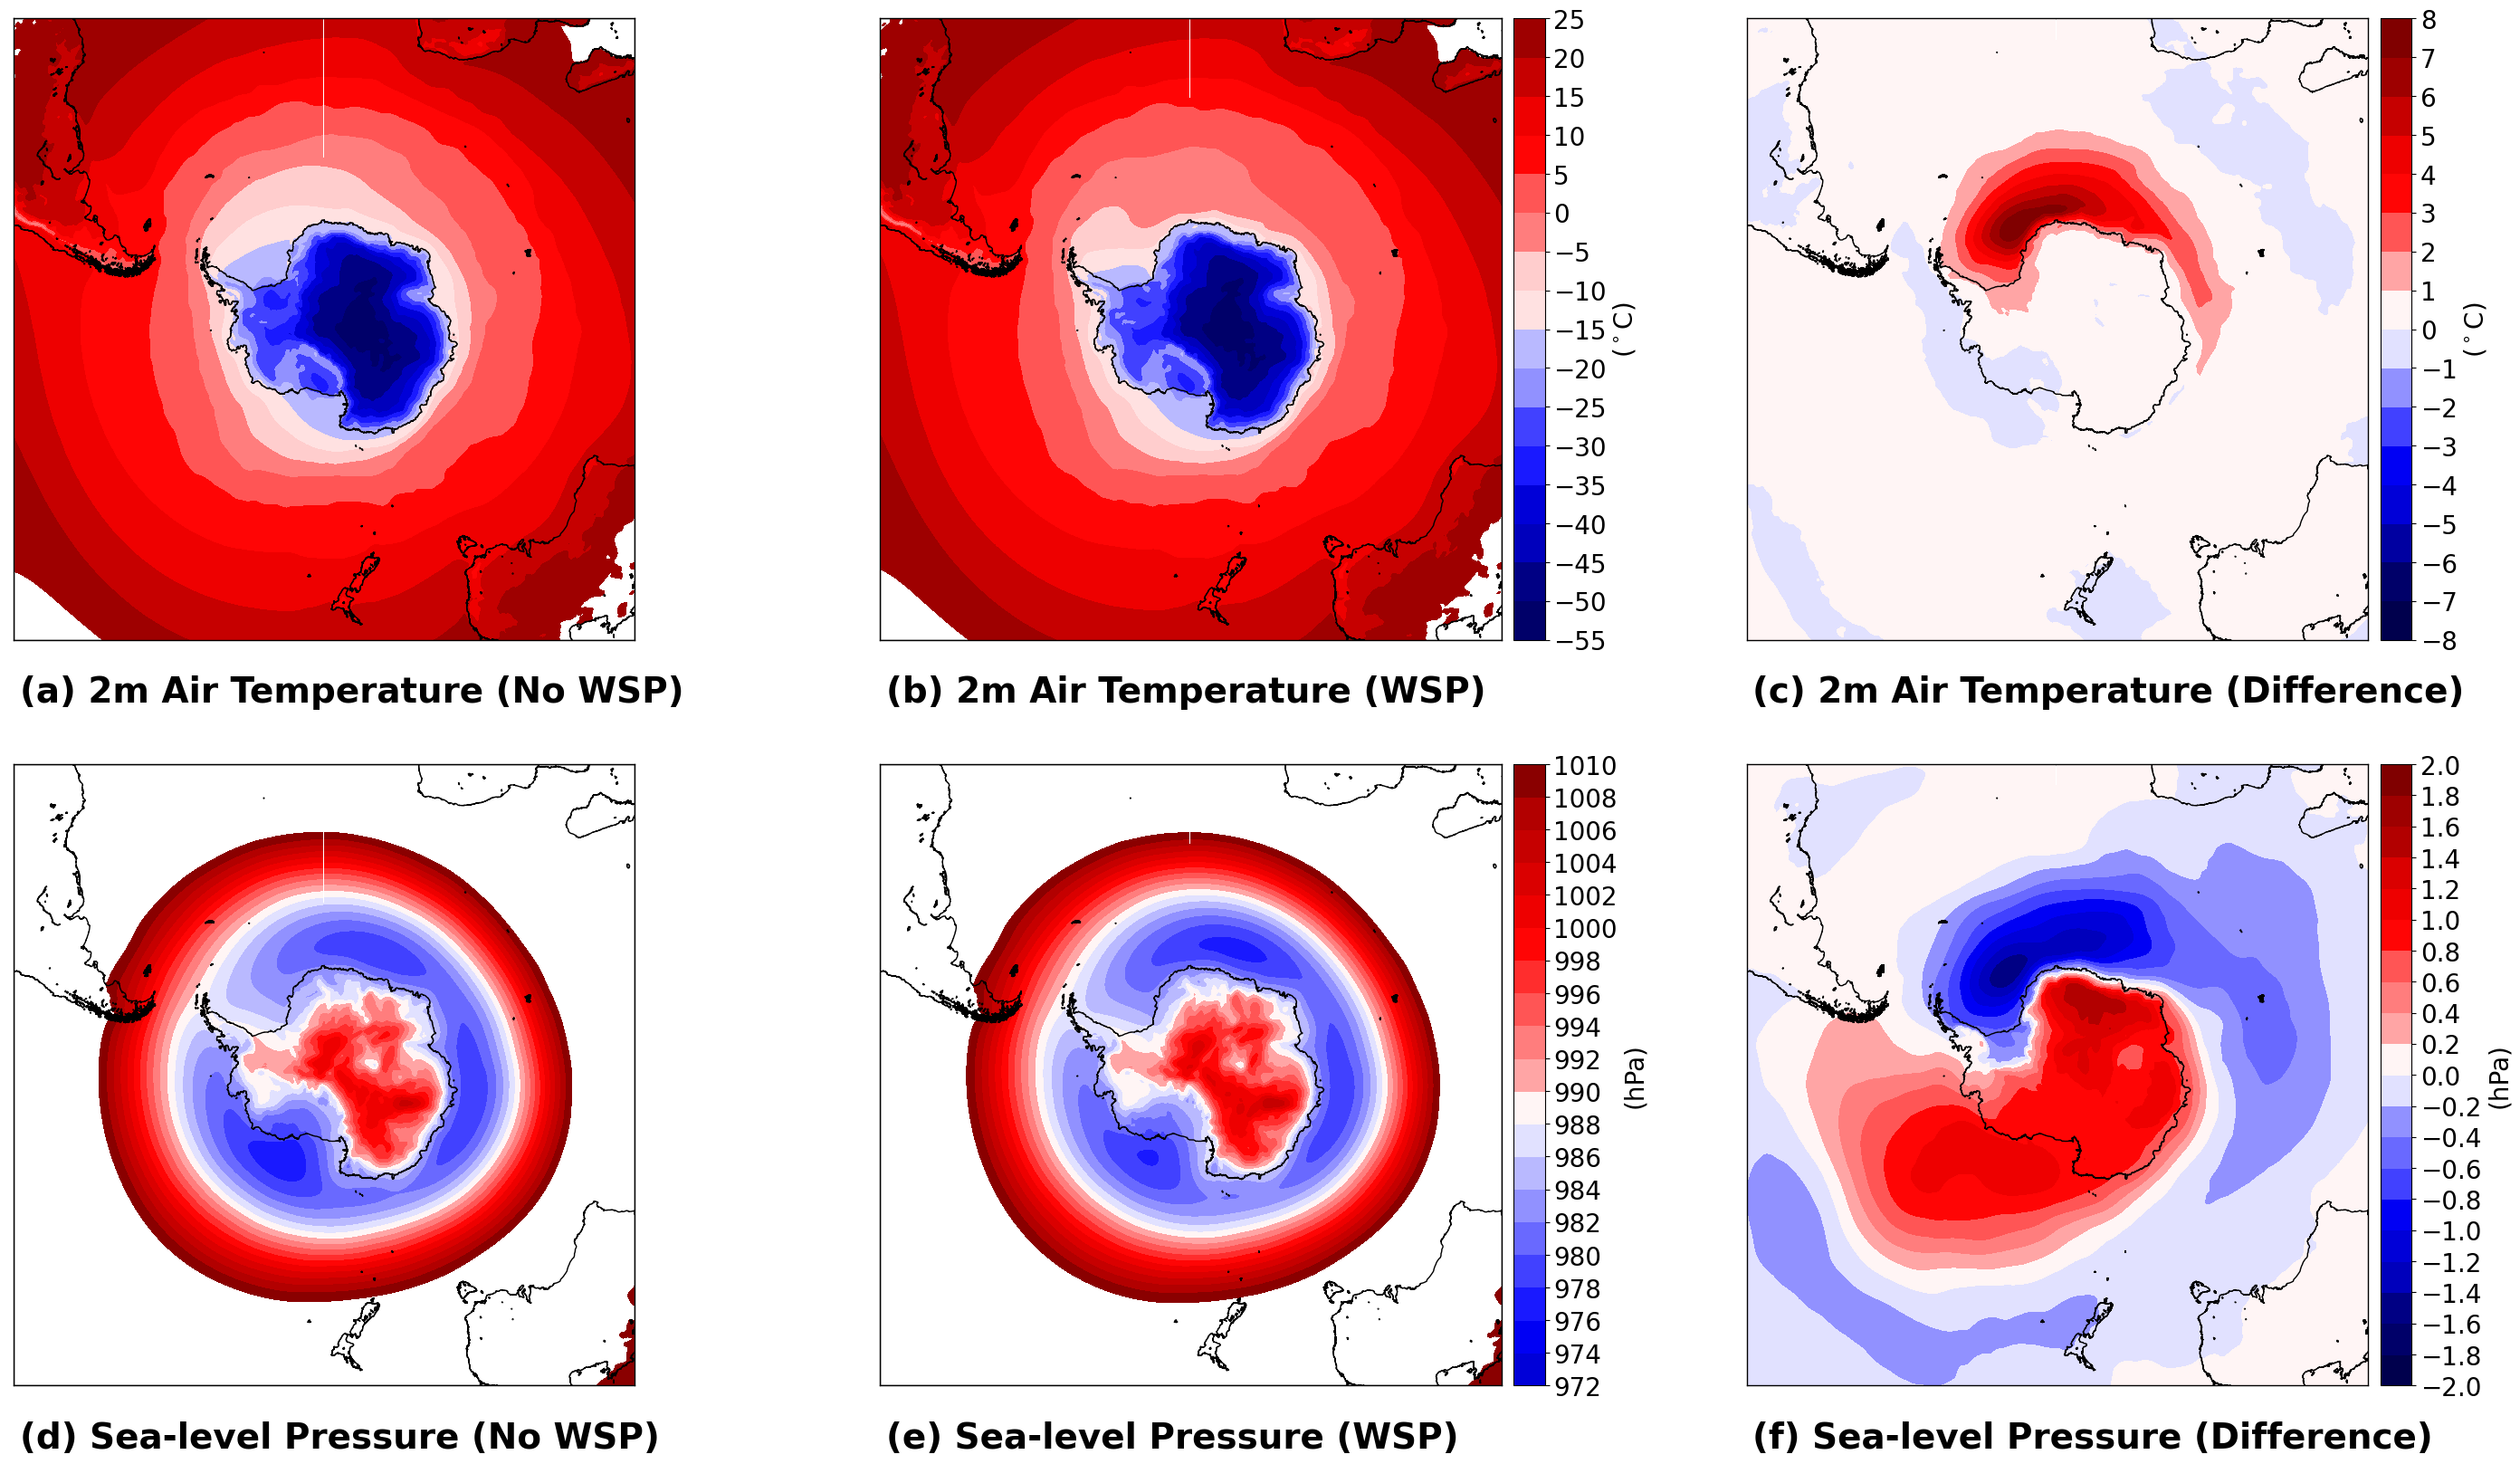

In [8]:
fig = plt.figure(figsize=(35,20), dpi=100)
#ax0 = fig.add_axes([0.1, 0.1, 0.8, 0.36],
                    #xticklabels=[])

ax1 = plt.subplot(2, 3, 1)
my_font = {'fontname':'Cambria', 'size':'20'}

##########################
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([10,20,30,40,50,60,70,80,90,100,110,120,135,140,150,160,170,180,190,\
                      200,210,220,230,240])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
#nice_levels = [-55,-50,-45,-40,-35,-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30,35,40,45,50,55]
nice_levels = [-55,-50,-45,-40,-35,-30,-25,-20,-15,-10,-5,0,5,10,15,20,25]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#********************************************************************
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 12900000,height = 12900000,resolution ='h') 
map.drawcoastlines()
#map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(xx,yy)
CP = map.contourf(x,y,TEMno[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=20) 
cbar.set_label('($^\circ$C)', **my_font)
cbar.remove()
#ax1.text(0.01, 0.01, '(a)', transform=ax1.transAxes,size=28, weight='bold',color='black')
ax1.text(0.01, -0.1, '(a) 2m Air Temperature (No WSP)', transform=ax1.transAxes,size=28, weight='bold',color='black')
#ax1.text(0.42, 0.48, 'TAUY', transform=ax1.transAxes,size=28, weight='bold')


ax2 = plt.subplot(2, 3, 2)
my_font = {'fontname':'Cambria', 'size':'20'}

#################################################################
##########################
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([10,20,30,40,50,60,70,80,90,100,110,120,135,140,150,160,170,180,190,\
                      200,210,220,230,240])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
#nice_levels = [-55,-50,-45,-40,-35,-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30,35,40,45,50,55]
nice_levels = [-55,-50,-45,-40,-35,-30,-25,-20,-15,-10,-5,0,5,10,15,20,25]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#********************************************************************
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 12900000,height = 12900000,resolution ='h') 
map.drawcoastlines()
#map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(xx,yy)
CP = map.contourf(x,y,TEMyes[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=20) 
cbar.set_label('($^\circ$C)', **my_font)
#ax2.text(0.01, 0.01, '(b)', transform=ax2.transAxes,size=28, weight='bold',color='black')
ax2.text(0.01, -0.1, '(b) 2m Air Temperature (WSP)', transform=ax2.transAxes,size=28, weight='bold',color='black')
#ax1.text(0.42, 0.48, 'TAUY', transform=ax1.transAxes,size=28, weight='bold')

    
ax3 = plt.subplot(2, 3, 3)
my_font = {'fontname':'Cambria', 'size':'20'}

#################################################################
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250,260])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 12900000,height = 12900000,resolution ='h') 
map.drawcoastlines()
#map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(xx,yy)
CP = map.contourf(x,y,TEMppp[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=20) 
cbar.set_label('($^\circ$C)', **my_font)
#ax3.text(0.01, 0.01, '(c)', transform=ax3.transAxes,size=28, weight='bold',color='black')
ax3.text(0.01, -0.1, '(c) 2m Air Temperature (Difference)', transform=ax3.transAxes,size=28, weight='bold',color='black')
#ax1.text(0.42, 0.48, 'TAUY', transform=ax1.transAxes,size=28, weight='bold')

ax1 = plt.subplot(2, 3, 4)
my_font = {'fontname':'Cambria', 'size':'20'}

#################################################################
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [972,974,976,978,980,982,984,986,988,990,992,994,996,998,1000,1002,1004,1006,1008,1010]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 12900000,height = 12900000,resolution ='h') 
map.drawcoastlines()
#map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(xx,yy)
CP = map.contourf(x,y,PSLno[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=20) 
cbar.set_label('(hPa)', **my_font)
cbar.remove()
ax1.text(0.01, -0.1, '(d) Sea-level Pressure (No WSP)', transform=ax1.transAxes,size=28, weight='bold',color='black')
#ax1.text(0.42, 0.48, 'TAUY', transform=ax1.transAxes,size=20, weight='bold')


ax2 = plt.subplot(2, 3, 5)
my_font = {'fontname':'Cambria', 'size':'20'}

#################################################################
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [972,974,976,978,980,982,984,986,988,990,992,994,996,998,1000,1002,1004,1006,1008,1010]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 12900000,height = 12900000,resolution ='h') 
map.drawcoastlines()
#map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(xx,yy)
CP = map.contourf(x,y,PSLyes[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=20) 
cbar.set_label('(hPa)', **my_font)

ax2.text(0.01, -0.1, '(e) Sea-level Pressure (WSP)', transform=ax2.transAxes,size=28, weight='bold',color='black')
#ax1.text(0.42, 0.48, 'TAUY', transform=ax1.transAxes,size=20, weight='bold')

    
ax3 = plt.subplot(2, 3, 6)
my_font = {'fontname':'Cambria', 'size':'20'}

#################################################################
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250,260])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-2,-1.8,-1.6,-1.4,-1.2,-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 12900000,height = 12900000,resolution ='h') 
map.drawcoastlines()
#map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(xx,yy)
CP = map.contourf(x,y,ppp[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=20) 
cbar.set_label('(hPa)', **my_font)

ax3.text(0.01, -0.1, '(f) Sea-level Pressure (Difference)', transform=ax3.transAxes,size=28, weight='bold',color='black')
#ax1.text(0.42, 0.48, 'TAUY', transform=ax1.transAxes,size=20, weight='bold')


plt.savefig("FigSS5tempattern.png",bbox_inches='tight')